## Demo for modelling single-channel PSF from bead data

#### Setup environment

In [17]:
import sys
sys.path.append("..")
from psflearning.psflearninglib import psflearninglib
from psflearning import io
from psflearning.makeplots import *
import tensorflow as tf
#main_data_dir = io.param.load('datapath.yaml').main_data_dir
try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('Running on GPU')
except:
    print('Running on CPU')

Running on GPU


#### Create psflearning object and load the config file
$\small\color{skyblue}{\mathrm{basefile}}$: config file with all parameters  
$\small\color{skyblue}{\mathrm{psftype}}$:  `'voxel', 'zernike'`  
$\small\color{skyblue}{\mathrm{sysfile}}$: config file with microscope specific parameters  
For advanced user, pass in base file only as below to interact with all parameters:   
```python
    L.param = io.param.combine('config_user')
```

In [55]:
L = psflearninglib()
L.param = io.param.combine('config_base',psftype='zernike',channeltype='2ch',sysfile='smart_tirf')


#### Edit user defined parameters

In [56]:
L.param.datapath = r'C:\Users\Sheng\Documents\MATLAB\bead100nm_smart\04-18-2025 2ch/'
L.param.keyword = 'bead1_100nm_darkred_mag502025-04-18_10-55-56' # keyword for your data file
L.param.savename = L.param.datapath+'2ch_psfmodel'
L.param.subfolder = '' # keyword for subfolder name if each data file is saved in a individual folder, set to '' if no subfolder
L.param.gain = 0.44
L.param.ccd_offset = 100
L.param.FOV.z_step = 1  
L.param.pixel_size.z = 0.1 # micron, equal to z_step*stepsize_of_the_data
L.param.roi.max_bead_number = 20 
L.param.roi.bead_radius = 0.0
L.param.ref_channel = 0 # choose the brighter channel as the reference channel, 0 or 1
L.param.batch_size = 30 # lower this number if out of memory
L.param.option.imaging.emission_wavelength = 0.68 # micron
L.param.roi.peak_height = 0.1



#### Start learning

In [60]:
images = L.load_data()

(2, 1, 21, 1152, 2304)


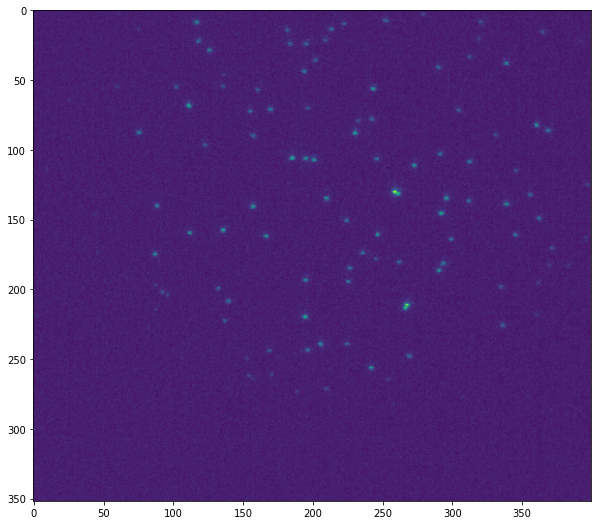

In [63]:
plt.figure(figsize=(10, 10))
plt.imshow(images[0][0][10])

In [62]:
images = images[:,:,:,800:,1400:1800]


In [75]:
images.shape

(2, 1, 21, 352, 400)

In [64]:
L.getpsfclass()

In [65]:
L.param.roi.roi_size = [19,19]
L.param.roi.peak_height = 0.3
#L.param.FOV.y_center = 900
#L.param.FOV.x_center = 1620
#L.param.FOV.radius = 240
dataobj = L.prep_data(images)

rois shape channel 0: (20, 21, 19, 19)
rois shape channel 1: (20, 21, 19, 19)
rois shape channel 0: (15, 21, 19, 19)
rois shape channel 1: (15, 21, 19, 19)


In [66]:
#images = L.load_data()
#L.getpsfclass()
#dataobj = L.prep_data(images)
for k in range(0,1): # increase iteration number if necessary
    psfobj,fitter = L.learn_psf(dataobj,time=0)
resfile = L.save_result(psfobj,dataobj,fitter)

3/6: learning: 53/100 [00:05s] 10.14it/s, current loss: 0.76261, total time: 5.23s
3/6: learning: 52/100 [00:05s] 10.29it/s, current loss: 0.69620, total time: 10.28s
3/6: learning: 91/250 [00:19s]  4.63it/s, current loss: 1.46365, total time: 29.91s
4/6: calculating spline coefficients: 2/2 [00:01s]  1.03it/s total time: 31.85s
5/6: localization: 5/5 [00:03s]  1.66it/s total time: 34.86s


outlier id: [ 1  2  7 14]
rois shape channel 0: (11, 21, 19, 19)
rois shape channel 1: (11, 21, 19, 19)


3/6: learning: 57/250 [00:11s]  5.00it/s, current loss: 1.38981, total time: 46.25s
4/6: calculating spline coefficients: 2/2 [00:01s]  1.03it/s total time: 48.18s
5/6: localization: 5/5 [00:02s]  2.10it/s total time: 50.56s
6/6: saving results: [00:03s] total time: 54.44s


#### Show results

In [67]:
f,p = io.h5.load(resfile) # load result file

channel 0


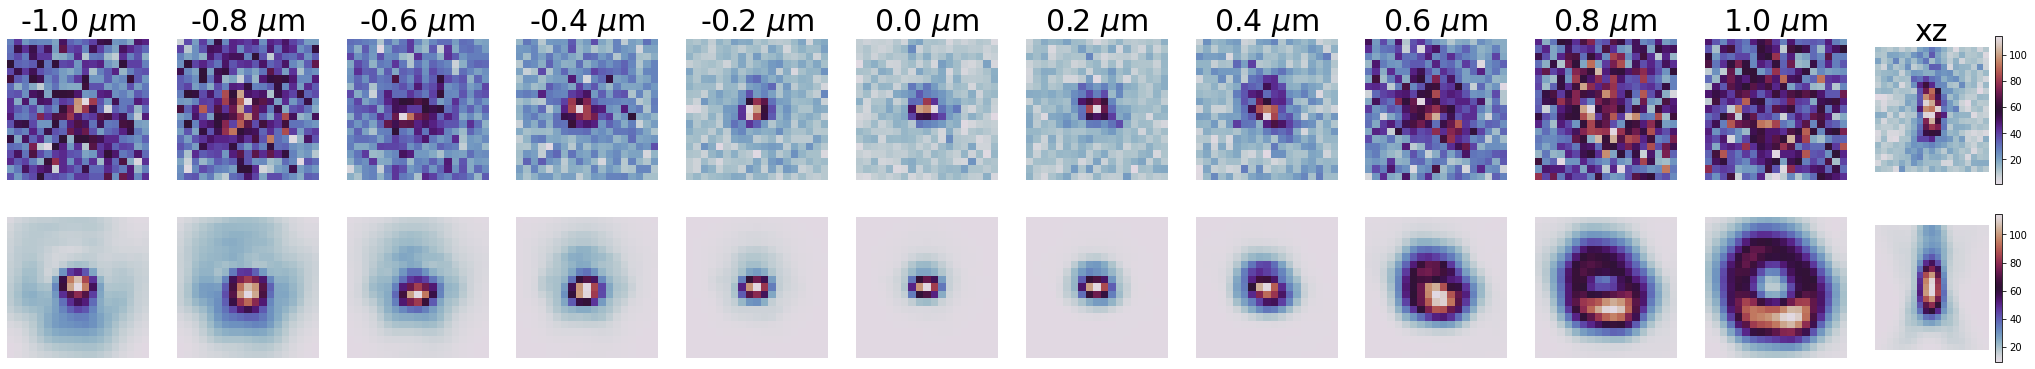

channel 1


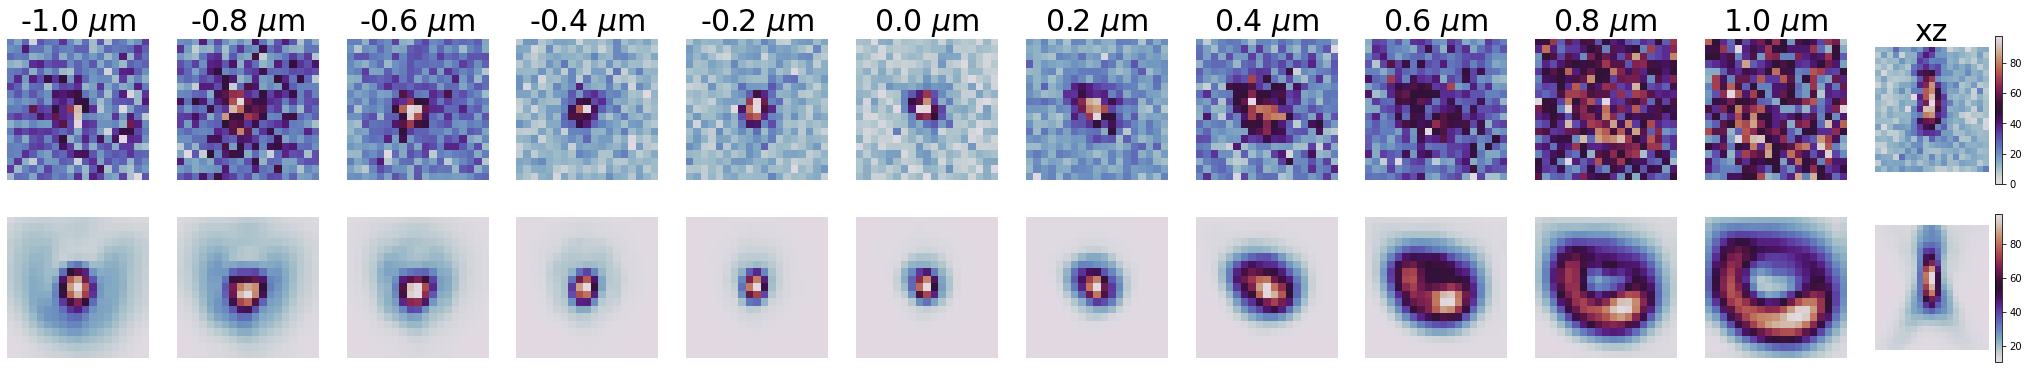

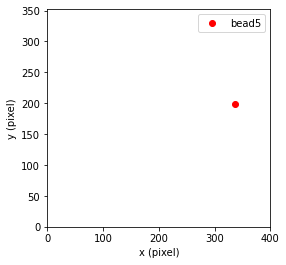

In [68]:
showpsfvsdata(f,p,index=5,step=2)

In [69]:
[f.res.channel0.sigma,f.res.channel1.sigma]

[array([0.6237, 0.6028], dtype=float32),
 array([0.6184, 0.6977], dtype=float32)]

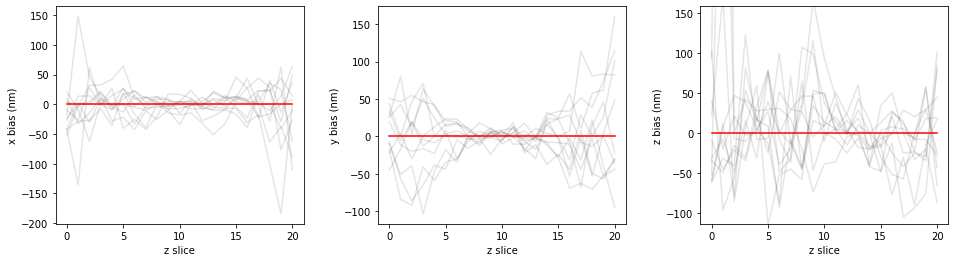

In [70]:
showlocalization(f,p)

#### Optional plots

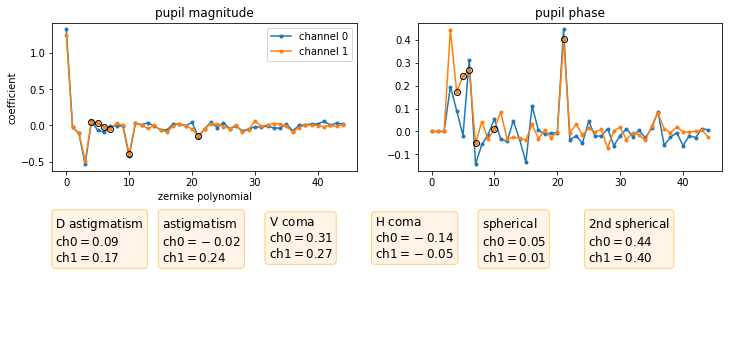

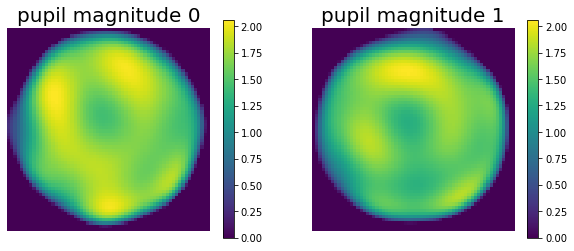

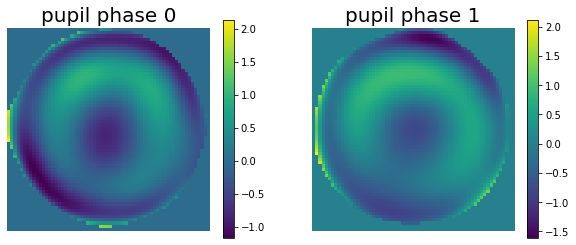

In [71]:
try:
    showzernike(f,p)
except:
    try: 
        showpupil(f,p)
    except:
        print('no pupil')

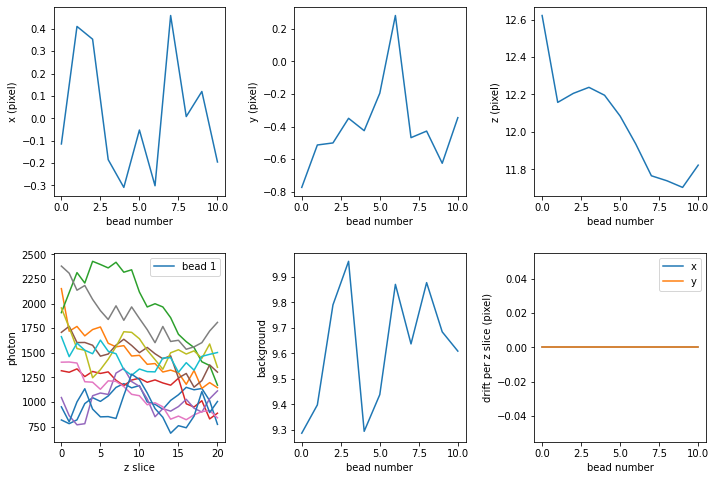

In [72]:
showlearnedparam(f,p)

[[ 1.0014 -0.0026 -0.    ]
 [ 0.0016  0.9998 -0.    ]
 [59.6787 -3.252   1.    ]]


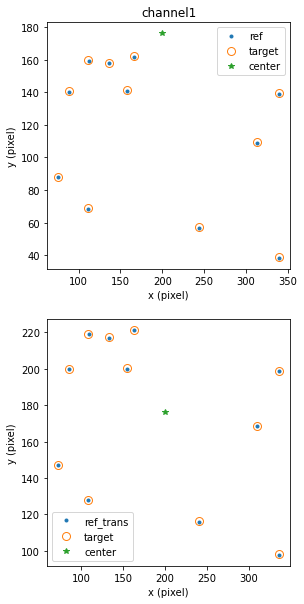

In [73]:
showtransform(f)
np.set_printoptions(precision=4,suppress=True)
print(f.res.T)

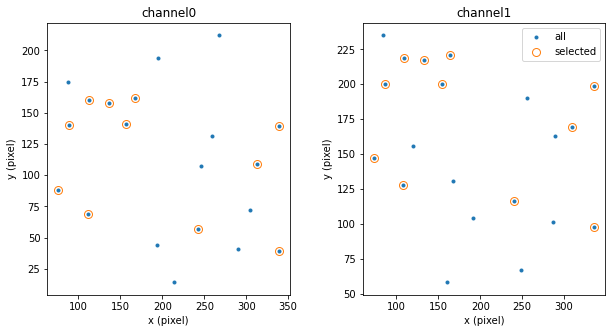

In [74]:
showcoord(f,p)

#### Ouput parameters

In [11]:
print('f:\n    ',list(f.keys()))
print(' locres:\n    ',list(f.locres.keys()))
print(' res:\n    ',list(f.res.keys()))
print(' rois:\n    ',list(f.rois.keys()))

f:
     ['locres', 'res', 'rois']
 locres:
     ['CRLB', 'LL', 'P', 'coeff', 'coeff_bead', 'coeff_reverse', 'loc']
 res:
     ['I_model', 'I_model_bead', 'I_model_reverse', 'apodization', 'bg', 'cor', 'cor_all', 'drift_rate', 'intensity', 'offset', 'pos', 'pupil', 'sigma', 'zernike_coeff', 'zernike_polynomial']
 rois:
     ['cor', 'fileID', 'image_size', 'psf_data', 'psf_fit']
